# Medium (NAIBR)
Here, we visualize the inversions that were identified for the `medium` treatment across the range of depths.

In [1]:
library(ggplot2)
library(dplyr)
library(ggpubr)
.size <- "medium"


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




These are the setup functions that process that data.

In [2]:
read_data <- function(size_treatment, depth){
    .depth <- paste("depth",depth, sep = "_")
    samplesfile <- paste("../../simulated_data/visor/called_sv/naibr", size_treatment, .depth, "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("../../simulated_data/visor/called_sv/naibr", size_treatment, .depth, "by_pop/inversions.bedpe", sep = "/")

    sample_inversions <- read.table(samplesfile, header = T)[,c(1:3,5)]
    names(sample_inversions) <- c("sample", "contig", "position_start", "position_end")
    if( nrow(sample_inversions) > 0){
        sample_inversions$size <- size_treatment
        sample_inversions$sample <- as.integer(gsub("sample_", "", sample_inversions$sample))
    }

    pooled_inversions <- read.table(poolfile, header = T)[,c(1:3,5)]
    names(pooled_inversions) <- c("sample", "contig", "position_start", "position_end")
    if( nrow(pooled_inversions) > 0){
        pooled_inversions$sample <- 11
        pooled_inversions$size <- size_treatment
    }
    outdf <- rbind(sample_inversions, pooled_inversions)
    if(nrow(outdf) > 0){
        outdf$depth <- depth
    }
    return(outdf)
}

read_all_data <- function(size_treatment){
    depth <- 0.5
    .data <- read_data(size_treatment, depth)    
    for(i in c(2,5,10,20)){
        .data <- rbind(.data, read_data(size_treatment, i))    
    }
    return(.data[,c(4,1,2,3,5,6)])
}

In [ ]:
SV <- read_all_data(.size)
head(samplesSV)

,position_end,sample,contig,position_start,size,depth
,<int>,<dbl>,<chr>,<int>,<chr>,<dbl>
1,24381093,9,3R,24237778,medium,0.5
2,6636805,4,2L,6436507,medium,0.5
3,24381167,3,3R,24237620,medium,0.5
4,17423851,2,2L,17056021,medium,0.5
5,17423948,8,2L,17055843,medium,0.5
6,18696449,8,2R,18236090,medium,0.5


Read in the sample and pool simulation inventory

In [5]:
performance <- read.table("../../assess_sv_leviathan/visor/inversion.assessment", header = T)
performance <- performance[performance$size == .size,]
performance$assessment <- ifelse(performance$simulated, "false negative", "true negative")
head(performance)

,contig,inversion,id,depth,sample,size,simulated,zygosity,position_start,position_end,assessment
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>
1101,2L,1,1,0.5,1,medium,TRUE,homozygous,1591146,1776073,false negative
1102,2L,1,1,2.0,1,medium,TRUE,homozygous,1591146,1776073,false negative
1103,2L,1,1,5.0,1,medium,TRUE,homozygous,1591146,1776073,false negative
1104,2L,1,1,10.0,1,medium,TRUE,homozygous,1591146,1776073,false negative
1105,2L,1,1,20.0,1,medium,TRUE,homozygous,1591146,1776073,false negative
1106,2L,1,1,0.5,2,medium,TRUE,homozygous,1591146,1776073,false negative


### Assess the performance of identified inversions

In [6]:
near_breakpoint <- function(x, y, tolerance = 75){
    # x is the simulated/known breakpoints
    # y is the breakpoint we want to compare
    # check if y is within tolerance of x
    return(
        (y >= x - tolerance) & (y <= x + tolerance)
    )
}

In [7]:
false_positives <- samplesSV[0,]

for(i in 1:nrow(samplesSV)){
    .row <- samplesSV[i,]
    query <- which(
        performance$sample == .row$sample &
        performance$depth == .row$depth &
        performance$contig == .row$contig &
        near_breakpoint(performance$position_start, .row$position_start, 1000) &
        near_breakpoint(performance$position_end, .row$position_end, 1000)
    )
    if(length(query) > 0 && performance$simulated[query]){
        performance$assessment[query] <- "true positive"
    } else {
        performance$assessment[query] <- "false positive"
        false_positives <- rbind(false_positives, .row)
    }
}
head(performance)
head(false_positives)
if (nrow(false_positives) > 0) {
    false_positives$size <- .size
    false_positives$method <- "naibr"
    write.table(false_positives, file = paste0("false_positives.", .size), row.names = F, quote = F)
}

,contig,inversion,id,depth,sample,size,simulated,zygosity,position_start,position_end,assessment
,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<lgl>,<chr>,<int>,<int>,<chr>
1101,2L,1,1,0.5,1,medium,TRUE,homozygous,1591146,1776073,false negative
1102,2L,1,1,2.0,1,medium,TRUE,homozygous,1591146,1776073,true positive
1103,2L,1,1,5.0,1,medium,TRUE,homozygous,1591146,1776073,true positive
1104,2L,1,1,10.0,1,medium,TRUE,homozygous,1591146,1776073,true positive
1105,2L,1,1,20.0,1,medium,TRUE,homozygous,1591146,1776073,true positive
1106,2L,1,1,0.5,2,medium,TRUE,homozygous,1591146,1776073,false negative


,position_end,sample,contig,position_start,size,depth
,<int>,<dbl>,<chr>,<int>,<chr>,<dbl>
134,26510571,11,2L,6636043,medium,5
135,6887630,11,2L,6636005,medium,5
136,8403019,11,2L,6636028,medium,5
227,21809650,11,2L,6636019,medium,10
228,6887583,11,2L,6636016,medium,10
229,29881990,11,2L,6636107,medium,10


Augment the table to capture all the inversions that were simulated (groundtruth for plotting purposes)

In [8]:
truth <- filter(performance, simulated) %>%
    select(contig, inversion, position_start, position_end) |> unique() %>%
    mutate(assessment = "true positive", sample = 0, depth = 20)

head(truth)

,contig,inversion,position_start,position_end,assessment,sample,depth
,<chr>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>
1,2L,1,1591146,1776073,true positive,0,20
56,2L,2,6436329,6636405,true positive,0,20
111,2L,3,17056243,17424245,true positive,0,20
166,2L,4,20404853,20474308,true positive,0,20
221,2R,1,9640874,9978281,true positive,0,20
276,2R,2,15862083,16302028,true positive,0,20


### Single-Sample Detection
Let's first visualize what detection looked like across the genome. Here, we facet across contigs and show all the depths at once. Since the small inversions are indeed quite small, for visualization purposes, we'll make each of them 100 kb bigger.

In [9]:
plot_inversions <- function(data, groundtruth, size_treatment){
    options(warn = -1, repr.plot.width = 19, repr.plot.height = 10)
    rbind(
        filter(data) %>% select(contig, position_start, position_end, depth, sample),
        select(groundtruth, contig, position_start, position_end, depth, sample)
    ) %>%
    ggplot(
        aes(
            x = sample,
            ymin = position_start,
            ymax = position_end+100000,
            color = as.factor(depth),
        )
    ) +
        geom_linerange(position = position_dodge(0.7), linewidth = 1.5) +
        coord_flip() +
        scale_color_brewer(name = "sequencing depth", palette = "Set2") +
        scale_x_continuous(breaks = 0:11,limits = c(0, 11)) +
        scale_y_continuous(labels = scales::comma) +
        theme_light() +
        theme(
            panel.grid.major.y = element_blank(),
            legend.position = "top",
            panel.grid.minor.y = element_line(color = "gray80", size = 0.5)
        ) +
        labs(
            title = "Simulated and Called Inversions Across the Genome",
            subtitle = paste0("Size: ", size_treatment),
            y = "genomic position (bp)",
            caption = "sample 0 = groundtruth | sample 11 = pooled"
        ) + 
        facet_grid(cols = vars(contig))
}

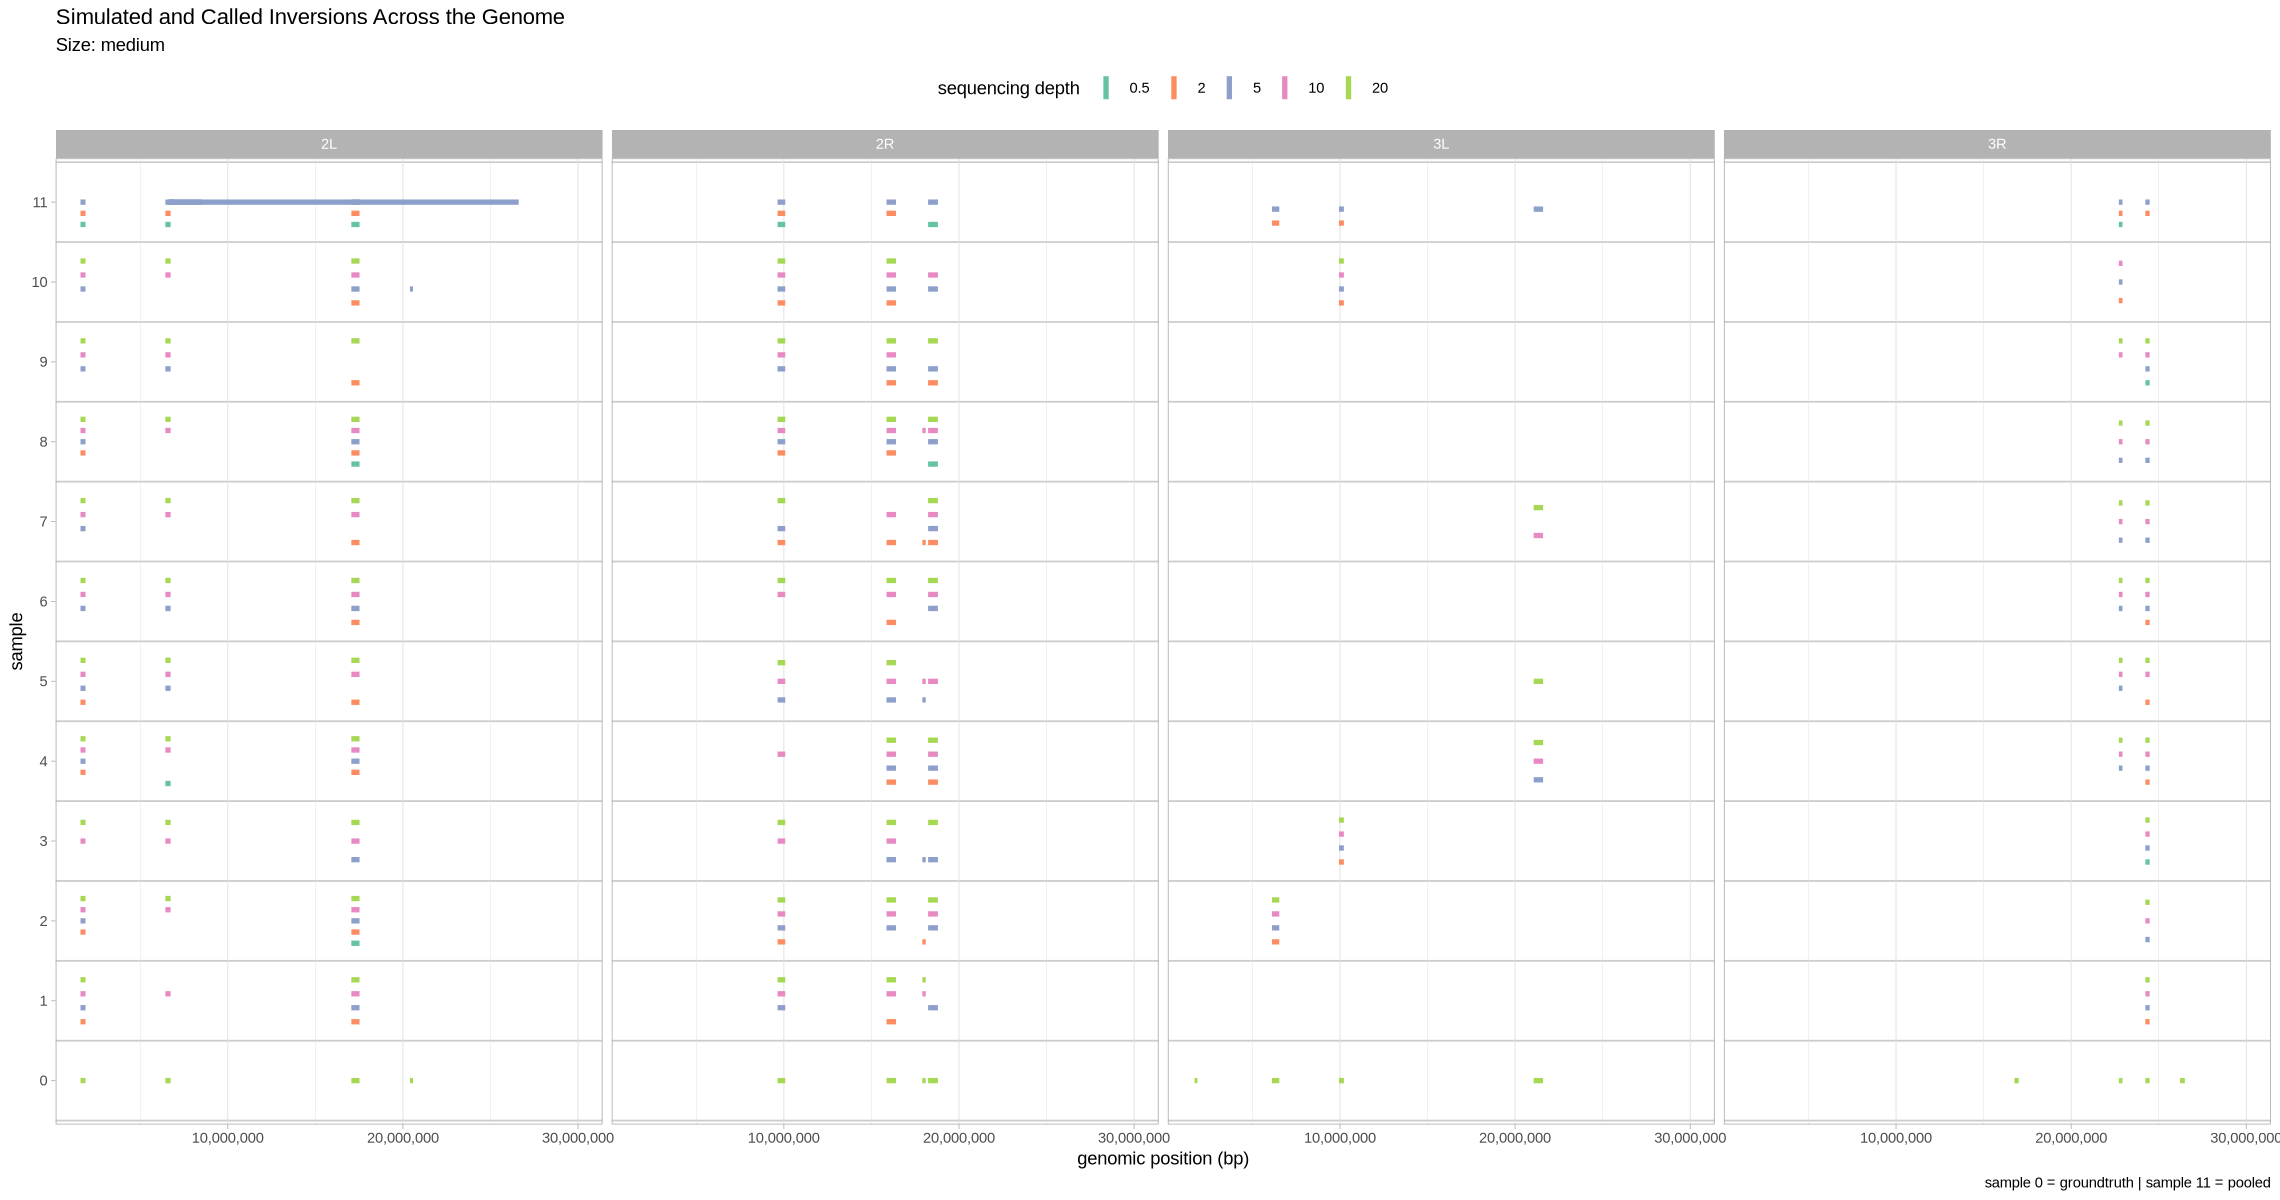

In [10]:
plot_inversions(samplesSV, truth, .size)

What does this look like as a heatmap of true/false positive/negative?

In [16]:
plot_samples_scattermatrix <- function(data, size_treatment){
    options(warn = -1, repr.plot.width = 8, repr.plot.height = 15)
    .data <- data[data$sample != 11,]
    axis_ticks <- factor(paste0("sample_", sprintf("%02d", 1:10)))
    ggplot(.data, aes(y = sample, x = inversion, color = assessment, fill = assessment, shape = zygosity)) +
        geom_point(size=6) +
        theme_light() +
        labs(title = "By-Sample Inversion Detection", subtitle = paste(size_treatment, "inversions detected in individual samples, as a function of zygotic state.")) +
        scale_color_manual(name = "Assessment", values = c("false negative" = "grey75", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_fill_manual(name = "Assessment", values = c("false negative" = "white", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_shape_manual(name = "Zygosity", values = c("homozygous" = 21, "heterozygous" = 22)) +
        scale_x_discrete(name = "Inversion") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(cols = vars(contig), rows = vars(depth))
}

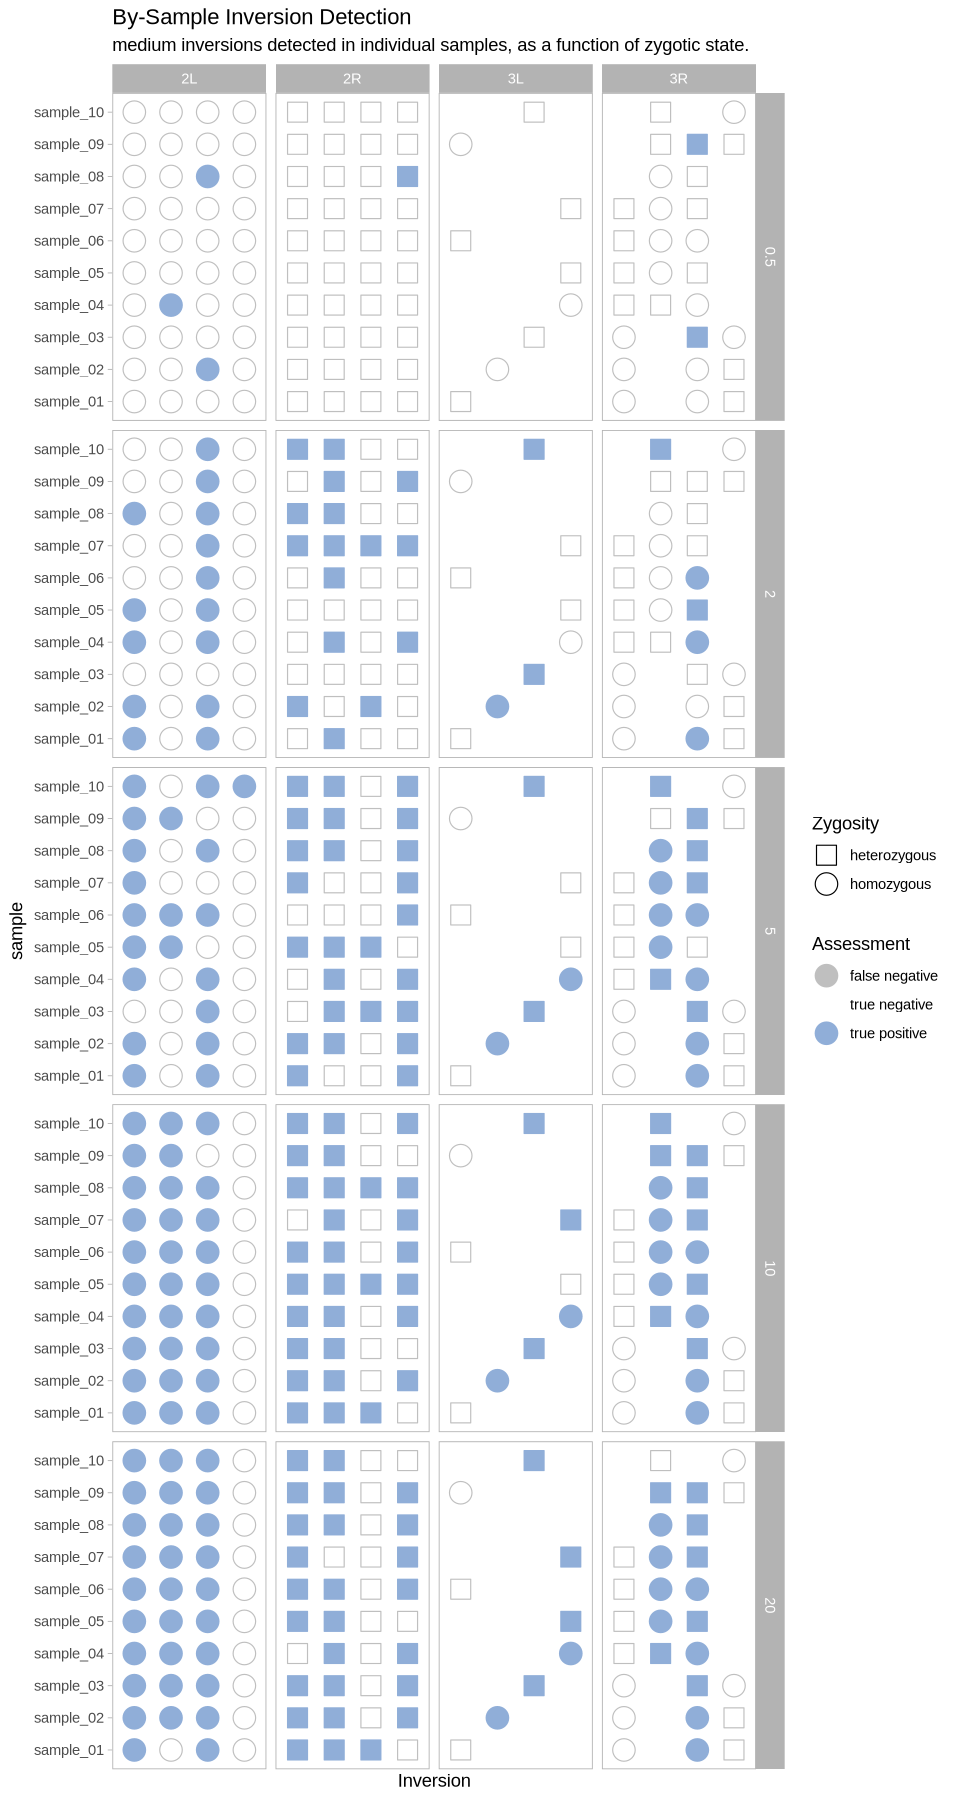

In [17]:
plot_samples_scattermatrix(performance, .size)

### Pooled Sample Detection 

In [18]:
plot_pools_matrix <- function(data, size_treatment){
    options(warn = -1, repr.plot.width = 12, repr.plot.height = 5)
    .data <- data[data$sample == 11,]
    .data$contig <- gsub("2L", "hom", .data$contig)
    .data$contig <- gsub("2R", "het", .data$contig)
    .data$contig <- gsub("3L", "rare", .data$contig)
    .data$contig <- gsub("3R", "common", .data$contig)
    .data$contig <- factor(.data$contig,levels = c("hom","het","common", "rare"), ordered = T)

    ggplot(.data, aes(y = 1, x = inversion, color = assessment, fill = assessment)) +
        geom_point(size = 16, shape = 22) +
        theme_light() +
        labs(title = "Pooled-Sample Detection", subtitle = paste(size_treatment, "inversions detected in sample-pooled data, as a function of inversion frequency in the population.")) +
        scale_color_manual(name = "Assessment", values = c("false negative" = "grey75", "true positive" = "#90aed8")) +
        scale_fill_manual(name = "Assessment", values = c("false negative" = "white", "true negative" = "white", "true positive" = "#90aed8")) +
        scale_y_continuous(breaks = 1, name = "Assessment") +
        scale_x_discrete(name = "Inversion") +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank()
        ) +
        facet_grid(cols = vars(contig), rows = vars(depth))
}

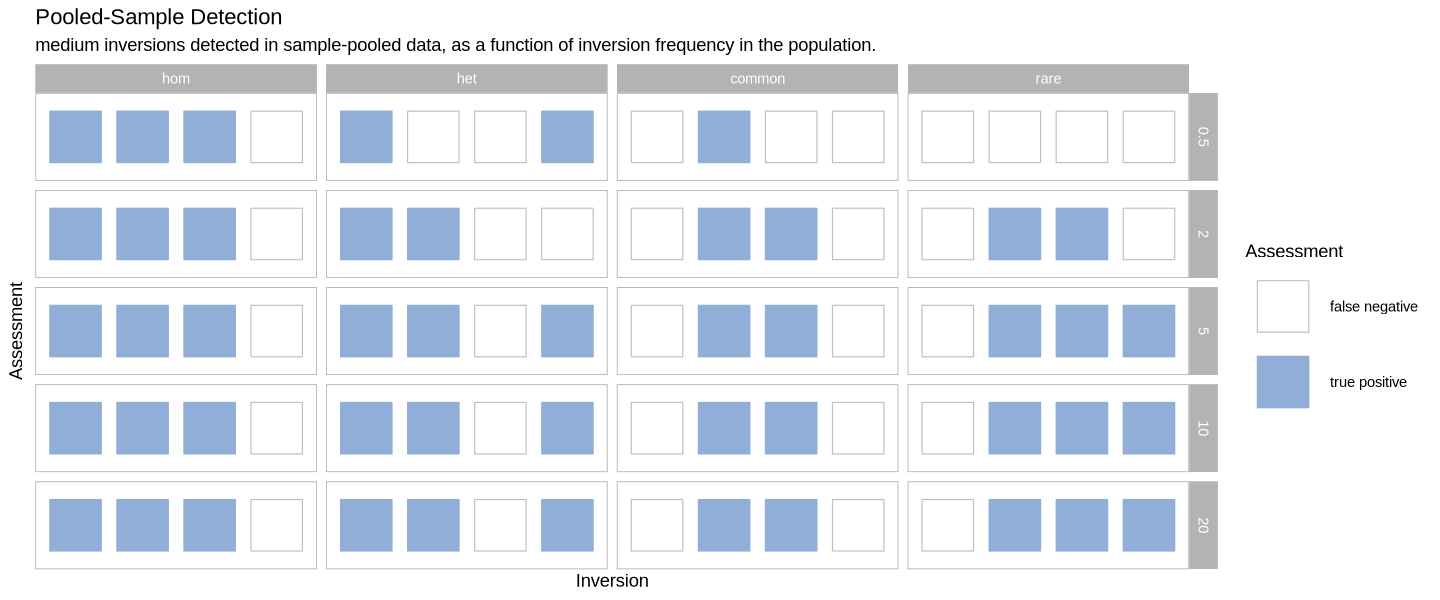

In [19]:
plot_pools_matrix(performance, .size)

Write this all to a file to tease apart later

In [20]:
write.csv(performance, file = paste0(.size, ".sv.naibr.assessment"), quote = F, row.names = F)